In [1]:
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback
)
import torch
import numpy as np
from datasets import Dataset
import evaluate
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Install necessary packages if not installed
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer
from datasets import Dataset
import evaluate
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import ast
from collections import Counter

# -------------------------
# 1. Load Dataset
# -------------------------
df = pd.read_csv("final_data_BIO.csv")
df["Tokenized_Text"] = df["Tokenized_Text"].apply(ast.literal_eval)
df["NER_Label_Sequence"] = df["NER_Label_Sequence"].apply(ast.literal_eval)

In [3]:

# -------------------------
# Word-level label distribution analysis
# -------------------------
label_counter = Counter()
for seq in df["NER_Label_Sequence"]:
    label_counter.update(seq)

total_tokens = sum(label_counter.values())

print("\nWord-level label distribution (BEFORE split):")
for label, count in label_counter.most_common():
    print(f"{label:10s}: {count:7d} ({count/total_tokens:.2%})")



Word-level label distribution (BEFORE split):
O         :  264329 (96.31%)
I-SYMPTOM :    2395 (0.87%)
B-SYMPTOM :    2021 (0.74%)
B-DISEASE_DISORDER:    1478 (0.54%)
I-DISEASE_DISORDER:    1442 (0.53%)
B-MEDICATION:     989 (0.36%)
I-PROCEDURE_TEST:     747 (0.27%)
B-PROCEDURE_TEST:     541 (0.20%)
I-MEDICATION:     527 (0.19%)


In [4]:
import random
from collections import Counter

# -------------------------
# Word-level O downsampling
# -------------------------
def downsample_O(tokens, labels, keep_ratio=0.005):
    new_tokens = []
    new_labels = []
    for t, l in zip(tokens, labels):
        if l == "O":
            if random.random() < keep_ratio:  # keep only a fraction of O
                new_tokens.append(t)
                new_labels.append(l)
        else:
            new_tokens.append(t)
            new_labels.append(l)
    return new_tokens, new_labels

# Apply to entire dataframe
df_downsampled = df.copy()
new_tokenized = []
new_labels = []

for t_seq, l_seq in zip(df_downsampled["Tokenized_Text"], df_downsampled["NER_Label_Sequence"]):
    t_new, l_new = downsample_O(t_seq, l_seq, keep_ratio=0.005)
    # skip empty sequences
    if len(t_new) > 0:
        new_tokenized.append(t_new)
        new_labels.append(l_new)

df_downsampled = pd.DataFrame({
    "Tokenized_Text": new_tokenized,
    "NER_Label_Sequence": new_labels
}).reset_index(drop=True)

# -------------------------
# Print new word-level distribution
# -------------------------
label_counter = Counter()
for seq in df_downsampled["NER_Label_Sequence"]:
    label_counter.update(seq)

total_tokens = sum(label_counter.values())

print("\nWord-level label distribution AFTER aggressive O downsampling:")
for label, count in label_counter.most_common():
    print(f"{label:10s}: {count:7d} ({count/total_tokens:.2%})")



Word-level label distribution AFTER aggressive O downsampling:
I-SYMPTOM :    2395 (20.82%)
B-SYMPTOM :    2021 (17.57%)
B-DISEASE_DISORDER:    1478 (12.85%)
I-DISEASE_DISORDER:    1442 (12.54%)
O         :    1363 (11.85%)
B-MEDICATION:     989 (8.60%)
I-PROCEDURE_TEST:     747 (6.49%)
B-PROCEDURE_TEST:     541 (4.70%)
I-MEDICATION:     527 (4.58%)


Map:   0%|          | 0/336 [00:00<?, ? examples/s]

Map:   0%|          | 0/144 [00:00<?, ? examples/s]

A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,1.146539,0.513111,0.579463,0.544272,0.608976
2,No log,0.811812,0.620206,0.678739,0.648154,0.715839
3,No log,0.709835,0.683831,0.727098,0.704801,0.756600
4,No log,0.681061,0.703982,0.738176,0.720674,0.766737
5,No log,0.659819,0.721024,0.762037,0.740963,0.779831


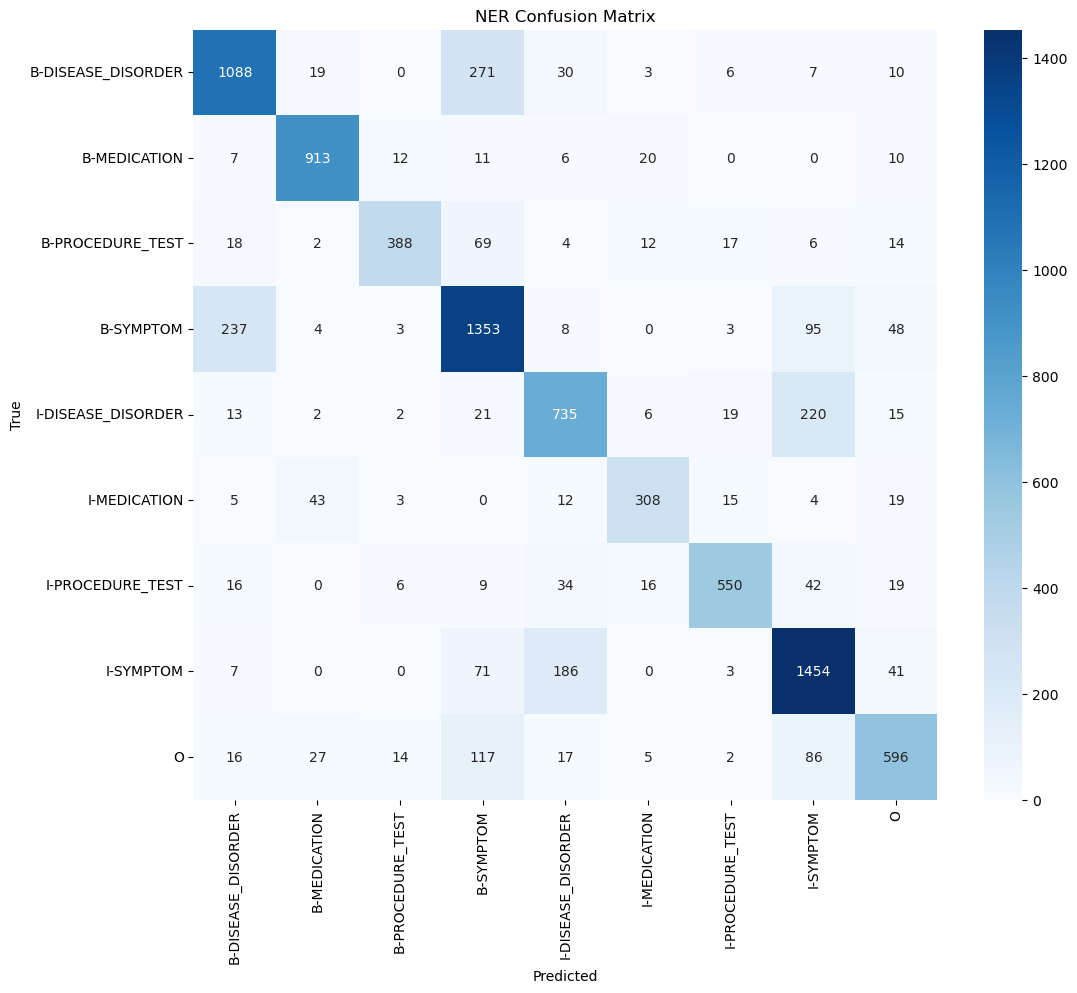

In [5]:

    
# Train-test split
train_df, test_df = train_test_split(df_downsampled, test_size=0.3, random_state=42)

# Convert to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# -------------------------
# 2. Tokenizer
# -------------------------
model_name = "bert-base-multilingual-cased"
# Use the fast tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

# Get unique labels
labels = list({l for seq in df['NER_Label_Sequence'] for l in seq})
labels.sort()
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}


# Tokenize and align labels
def tokenize_and_align_labels(examples):
    # Tokenize with truncation & padding
    tokenized_inputs = tokenizer(
        examples['Tokenized_Text'],
        truncation=True,
        padding='max_length',   # pad to max_length
        max_length=512,
        is_split_into_words=True
    )

    all_labels = []
    for i, labels in enumerate(examples['NER_Label_Sequence']):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)  # ignored token
            else:
                label_ids.append(label2id[labels[word_idx]])
        all_labels.append(label_ids)

    tokenized_inputs["labels"] = all_labels
    return tokenized_inputs


train_dataset = train_dataset.map(tokenize_and_align_labels, batched=True)
test_dataset = test_dataset.map(tokenize_and_align_labels, batched=True)

# Set format for PyTorch
train_dataset.set_format("torch")
test_dataset.set_format("torch")

# -------------------------
# 3. Model
# -------------------------
model = AutoModelForTokenClassification.from_pretrained(model_name, num_labels=len(labels), id2label=id2label, label2id=label2id)

# -------------------------
# 4. Metrics
# -------------------------


metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_labels = [[id2label[l] for l in label if l != -100] for label in labels]
    true_predictions = [[id2label[p] for (p, l) in zip(prediction, label) if l != -100] 
                        for prediction, label in zip(predictions, labels)]
    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }
# -------------------------
# 5. Training
# -------------------------
training_args = TrainingArguments(
    output_dir="./ner_model",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="./logs",
    save_strategy="epoch"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

# -------------------------
# 6. Confusion Matrix
# -------------------------
# Get predictions
preds_output = trainer.predict(test_dataset)
preds = np.argmax(preds_output.predictions, axis=2)
true_labels = test_dataset["labels"]

# Flatten for confusion matrix
preds_flat = []
labels_flat = []

for i in range(len(preds)):
    for j in range(len(preds[i])):
        if true_labels[i][j] != -100:
            preds_flat.append(preds[i][j])
            labels_flat.append(true_labels[i][j])

cm = confusion_matrix(labels_flat, preds_flat)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("NER Confusion Matrix")
plt.show()


In [6]:
# -------- Print All Test Metrics --------
test_metrics = trainer.evaluate(test_dataset)

for k, v in test_metrics.items():
    print(f"{k}: {v}")


eval_loss: 0.6598189473152161
eval_precision: 0.7210239870993751
eval_recall: 0.762036642522369
eval_f1: 0.7409632314862766
eval_accuracy: 0.779831045406547
eval_runtime: 4.1811
eval_samples_per_second: 34.44
eval_steps_per_second: 4.305
epoch: 5.0
